# Module 14: Decision Trees

## Learning Outcomes
- • Identify the correct statements regarding decision trees and their outputs.
- • Build a decision tree manually.
- • Articulate the correct inputs for building decision trees using scikit-learn and visualizing them using Graphiz.
- • Train a decision tree model with desired hyperparameters using scikit-learn.
- • Visualize a decision tree.
- • Evaluate decision tree splits.
- • Evaluate overfitting of decision trees.
- • Measure the impurity of a decision tree using entropy.
- • Compare the performance of different grid search algorithms.
- • Implement the decision tree algorithm.

## Key Activities
- • Videos 14.1–14.11
- • Mini-Lessons 14.1–14.5
- • Required Knowledge Checks 14.1–14.4
- • Required Codio Assignments 14.1–14.3
- • Required Discussion 14.1
- • Required Try-It Activity 14.2
- • Self-Study Colab Activities 14.1–14.3
- • Self-Study Try-It Activity 14.1

## Notes

## Example Code

## Summary



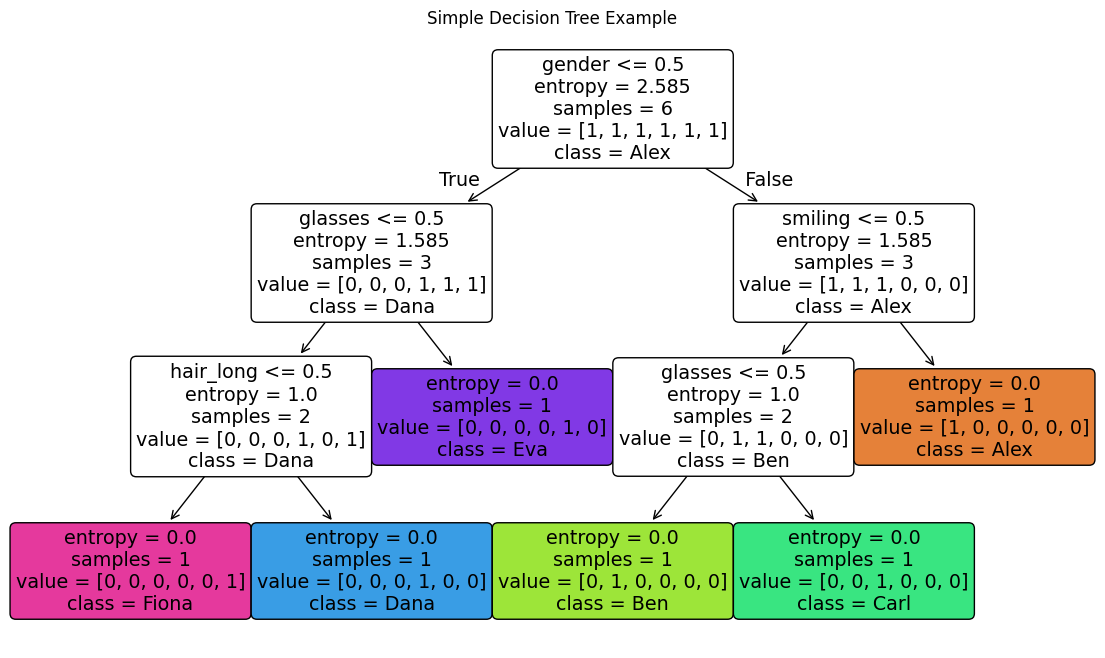

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# ----------------------------
# Sample "Guess Who?"-style data
# ----------------------------
# Features:
# gender: 0=female, 1=male
# glasses: 0=no, 1=yes
# smiling: 0=no, 1=yes
# hair_length: 0=short, 1=long
#
# Target:
# character_id (just a label)

data = {
    "gender":     [1, 1, 1, 0, 0, 0],
    "glasses":    [1, 0, 1, 0, 1, 0],
    "smiling":    [1, 0, 0, 1, 0, 1],
    "hair_long":  [0, 1, 0, 1, 1, 0],
    "character":  ["Alex", "Ben", "Carl", "Dana", "Eva", "Fiona"]
}

df = pd.DataFrame(data)

X = df[["gender", "glasses", "smiling", "hair_long"]]
y = df["character"]

# ----------------------------
# Train Decision Tree
# ----------------------------
model = DecisionTreeClassifier(
    criterion="entropy",   # information gain (easy to explain)
    max_depth=4,
    random_state=42
)

model.fit(X, y)

# ----------------------------
# Plot the tree
# ----------------------------
plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)
plt.title("Simple Decision Tree Example")
plt.show()

|--- gender <= 0.50
|   |--- glasses <= 0.50
|   |   |--- hair_long <= 0.50
|   |   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 0.00, 1.00] class: Fiona
|   |   |--- hair_long >  0.50
|   |   |   |--- weights: [0.00, 0.00, 0.00, 1.00, 0.00, 0.00] class: Dana
|   |--- glasses >  0.50
|   |   |--- weights: [0.00, 0.00, 0.00, 0.00, 1.00, 0.00] class: Eva
|--- gender >  0.50
|   |--- smiling <= 0.50
|   |   |--- glasses <= 0.50
|   |   |   |--- weights: [0.00, 1.00, 0.00, 0.00, 0.00, 0.00] class: Ben
|   |   |--- glasses >  0.50
|   |   |   |--- weights: [0.00, 0.00, 1.00, 0.00, 0.00, 0.00] class: Carl
|   |--- smiling >  0.50
|   |   |--- weights: [1.00, 0.00, 0.00, 0.00, 0.00, 0.00] class: Alex



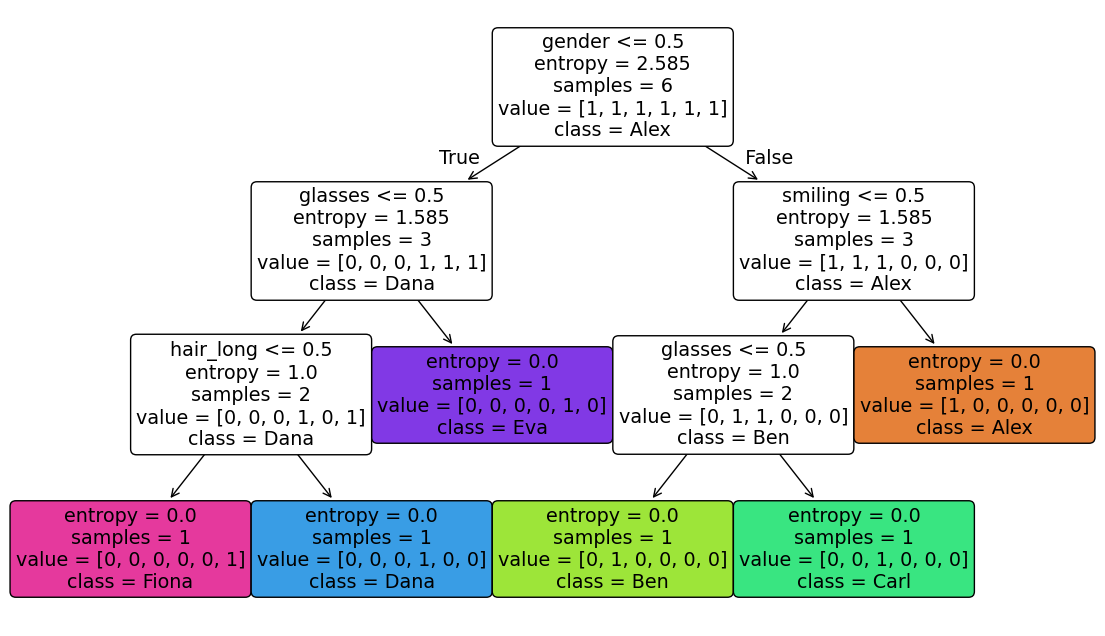

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

# Sample data
data = {
    "gender":     [1, 1, 1, 0, 0, 0],
    "glasses":    [1, 0, 1, 0, 1, 0],
    "smiling":    [1, 0, 0, 1, 0, 1],
    "hair_long":  [0, 1, 0, 1, 1, 0],
    "character":  ["Alex", "Ben", "Carl", "Dana", "Eva", "Fiona"]
}

df = pd.DataFrame(data)

X = df[["gender", "glasses", "smiling", "hair_long"]]
y = df["character"]

# Train tree
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X, y)

# Export text representation
tree_rules = export_text(
    model,
    feature_names=list(X.columns),
    show_weights=True
)

print(tree_rules)

# Plot tree (optional, visual)
plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)
plt.show()

Accuracy: 0.0
              precision    recall  f1-score   support

        Alex       0.00      0.00      0.00       1.0
         Ben       0.00      0.00      0.00       1.0
        Carl       0.00      0.00      0.00       0.0
       Fiona       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

|--- smiling <= 0.50
|   |--- gender <= 0.50
|   |   |--- class: Eva
|   |--- gender >  0.50
|   |   |--- class: Carl
|--- smiling >  0.50
|   |--- hair_long <= 0.50
|   |   |--- class: Fiona
|   |--- hair_long >  0.50
|   |   |--- class: Dana



/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisi

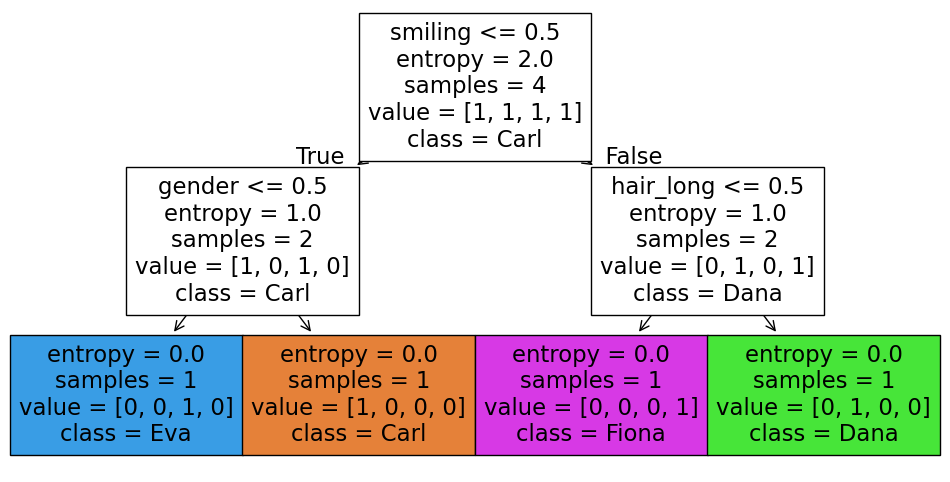

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Sample data
data = {
    "gender":     [1, 1, 1, 0, 0, 0],
    "glasses":    [1, 0, 1, 0, 1, 0],
    "smiling":    [1, 0, 0, 1, 0, 1],
    "hair_long":  [0, 1, 0, 1, 1, 0],
    "character":  ["Alex", "Ben", "Carl", "Dana", "Eva", "Fiona"]
}

df = pd.DataFrame(data)
X = df[["gender", "glasses", "smiling", "hair_long"]]
y = df["character"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

# Train model
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Text representation
print(export_text(model, feature_names=list(X.columns)))

# Visual tree
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()

Accuracy: 0.0
              precision    recall  f1-score   support

        Alex       0.00      0.00      0.00       1.0
         Ben       0.00      0.00      0.00       1.0
        Carl       0.00      0.00      0.00       0.0
       Fiona       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

|--- smiling <= 0.50
|   |--- gender <= 0.50
|   |   |--- class: Eva
|   |--- gender >  0.50
|   |   |--- class: Carl
|--- smiling >  0.50
|   |--- hair_long <= 0.50
|   |   |--- class: Fiona
|   |--- hair_long >  0.50
|   |   |--- class: Dana



/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/garcia/Documents/Coding/code4AI-governance/Berkeley/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisi

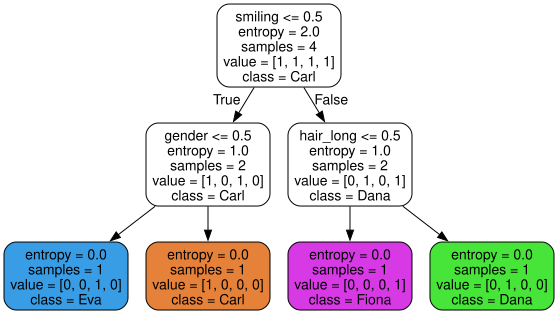

In [9]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import graphviz

# Sample data
data = {
    "gender":     [1, 1, 1, 0, 0, 0],
    "glasses":    [1, 0, 1, 0, 1, 0],
    "smiling":    [1, 0, 0, 1, 0, 1],
    "hair_long":  [0, 1, 0, 1, 1, 0],
    "character":  ["Alex", "Ben", "Carl", "Dana", "Eva", "Fiona"]
}

df = pd.DataFrame(data)
X = df[["gender", "glasses", "smiling", "hair_long"]]
y = df["character"]

# Train/test split (no stratify for this dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Train model
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))
print(classification_report(y_test, model.predict(X_test)))

# Text tree
print(export_text(model, feature_names=list(X.columns)))

# Graphviz visualization
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph